# 08 · Tópicos complementares
**GA033 · Módulo de introdução à programação científica**

Este notebook amplia o repertório com quatro problemas: encontrar uma raiz, ajustar parâmetros, interpolar dados e integrar uma equação diferencial ordinária.

**Pré-requisitos:** funções, arrays, gráficos e os cálculos básicos do notebook de SciPy. Os exemplos são pequenos e têm verificações próprias. Execute na ordem; os exercícios não alimentam as células posteriores.


## Quatro perguntas, quatro tipos de problema

| Pergunta | Objeto procurado | Interface usada aqui |
|---|---|---|
| Onde $f(x)=0$? | Uma raiz | root_scalar |
| Quais parâmetros aproximam os dados? | Parâmetros de um modelo | curve_fit |
| Como avaliar entre pontos conhecidos? | Uma função interpoladora | np.interp e CubicSpline |
| Como um estado evolui no tempo? | Uma solução de EDO | solve_ivp |

Essas perguntas exigem hipóteses diferentes. Vamos escrevê-las antes de chamar as rotinas.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import root_scalar, curve_fit
from scipy.interpolate import CubicSpline
from scipy.integrate import solve_ivp

## 1. Raízes: começar por um intervalo

Para $f(x)=x^2-2$, procuramos a raiz positiva $\sqrt2$. A função é contínua em $[0,2]$ e tem sinais opostos nos extremos. Isso garante pelo menos uma raiz no intervalo.

A bisseção preserva um intervalo contendo uma mudança de sinal e o divide sucessivamente. Não é necessário fornecer derivadas.


In [2]:
def f_raiz(x):
    return x**2 - 2.0


intervalo = (0.0, 2.0)
print("f(0):", f_raiz(intervalo[0]))
print("f(2):", f_raiz(intervalo[1]))
print("Produto dos valores nos extremos:", f_raiz(intervalo[0]) * f_raiz(intervalo[1]))

f(0): -2.0
f(2): 2.0
Produto dos valores nos extremos: -4.0


In [3]:
resultado_raiz = root_scalar(
    f_raiz, bracket=intervalo, method="bisect", xtol=1e-10, rtol=1e-12
)
print("Convergiu?", resultado_raiz.converged)
print("Raiz:", resultado_raiz.root)
print("Resíduo |f(raiz)|:", abs(f_raiz(resultado_raiz.root)))
print("Erro contra sqrt(2):", abs(resultado_raiz.root - np.sqrt(2.0)))
assert resultado_raiz.converged

Convergiu? True
Raiz: 1.4142135623260401
Resíduo |f(raiz)|: 1.3309153779061944e-10
Erro contra sqrt(2): 4.705502654189786e-11


A mudança de sinal garante existência sob continuidade, mas não garante unicidade. Uma função descontínua pode mudar de sinal sem ter raiz; uma raiz de multiplicidade par pode não produzir mudança de sinal.

O critério de parada usa tolerâncias sobre a posição da raiz. Também é útil inspecionar o resíduo e o estado de convergência; um resíduo pequeno sozinho não fornece um limite universal para o erro em $x$.


### Newton: fornecer a derivada explicitamente

Para comparar com Newton, usamos $f'(x)=2x$ e uma estimativa inicial próxima da raiz positiva. Diferentemente da bisseção, Newton não conserva automaticamente um intervalo com mudança de sinal.

Na interface **optimize.newton**, omitir a derivada seleciona secantes. Aqui especificamos o método e a derivada em **root_scalar**, deixando claro qual algoritmo foi solicitado.


In [4]:
def derivada_raiz(x):
    return 2.0 * x


resultado_newton = root_scalar(
    f_raiz,
    x0=1.5,
    fprime=derivada_raiz,
    method="newton",
    xtol=1e-10,
    rtol=1e-12,
)
print("Convergiu?", resultado_newton.converged)
print("Raiz:", resultado_newton.root)
print("Resíduo:", abs(f_raiz(resultado_newton.root)))
assert resultado_newton.converged

Convergiu? True
Raiz: 1.4142135623730951
Resíduo: 4.440892098500626e-16


Não existe um vencedor geral a partir deste exemplo. Escolher um método depende da função, da disponibilidade de intervalo ou derivadas, do custo das avaliações e das tolerâncias. Métodos como Brent e TOMS748 podem ser estudados depois com esses critérios.

### Exercício 1 · Outra raiz com bisseção

Encontre a raiz de $x^3-1$ em $[0,2]$. Verifique os sinais nos extremos, a convergência e a diferença para a raiz exata $x=1$.


In [5]:
def f_ex1(x):
    return x**3 - 1.0


resultado_ex1 = None  # Use root_scalar com method="bisect".
print("Sinais nos extremos:", f_ex1(0.0), f_ex1(2.0))
if resultado_ex1 is None:
    print("Preencha resultado_ex1 para conferir a raiz.")
else:
    print("Convergiu?", resultado_ex1.converged)
    print("Raiz:", resultado_ex1.root)

Sinais nos extremos: -1.0 7.0
Preencha resultado_ex1 para conferir a raiz.


<details>
<summary>Conferir uma solução do exercício 1</summary>

~~~python
from scipy.optimize import root_scalar

def f(x):
    return x**3 - 1.0

resultado = root_scalar(f, bracket=(0.0, 2.0), method="bisect", xtol=1e-10)
assert resultado.converged
assert abs(resultado.root - 1.0) < 1e-9
print(resultado.root, abs(f(resultado.root)))
~~~

A função é contínua, vale -1 em 0 e 7 em 2. Neste caso, a raiz já é o ponto médio do intervalo.

</details>


## 2. Ajuste de parâmetros: aproximar medições

Vamos gerar medições sintéticas de $y=ax+b$ com ruído. O modelo tem **dois parâmetros**, então a estimativa inicial também deve ter duas entradas.

O ajuste por mínimos quadrados procura reduzir
\[
S(a,b)=\sum_i [y_i-(ax_i+b)]^2.
\]
Esse modelo é linear nos parâmetros. Não precisamos de otimização global; **np.linalg.lstsq** também resolveria o problema. Usamos curve_fit para conhecer sua interface.


In [6]:
rng = np.random.default_rng(2026)
x_dados = np.linspace(0.0, 2.0, 15)
a_verdadeiro, b_verdadeiro = 1.5, 0.4
sigma = 0.08


def modelo_linear(x, a, b):
    return a * x + b


y_sem_ruido = modelo_linear(x_dados, a_verdadeiro, b_verdadeiro)
y_dados = y_sem_ruido + rng.normal(0.0, sigma, size=x_dados.size)
print("Cinco primeiras medições:", np.round(y_dados[:5], 3))

Cinco primeiras medições: [0.337 0.634 0.677 1.155 1.308]


In [7]:
parametros, covariancia = curve_fit(
    modelo_linear,
    x_dados,
    y_dados,
    p0=(1.0, 0.0),
    sigma=np.full(x_dados.shape, sigma),
    absolute_sigma=True,
)
a_ajustado, b_ajustado = parametros
residuos_ajuste = y_dados - modelo_linear(x_dados, *parametros)

print("Parâmetros ajustados:", parametros)
print("Parâmetros usados na geração:", [a_verdadeiro, b_verdadeiro])
print("Soma dos quadrados dos resíduos:", np.sum(residuos_ajuste**2))
print("Desvios-padrão dos parâmetros:", np.sqrt(np.diag(covariancia)))

Parâmetros ajustados: [1.52156119 0.37863904]
Parâmetros usados na geração: [1.5, 0.4]
Soma dos quadrados dos resíduos: 0.0476270663465776
Desvios-padrão dos parâmetros: [0.0334664  0.03932768]


Os parâmetros ajustados não precisam coincidir com os usados na geração: as medições têm ruído. Os desvios-padrão calculados a partir da covariância dependem das hipóteses do modelo e dos erros.

Neste exemplo, informamos o desvio-padrão conhecido de erros independentes. **absolute_sigma=True** pede que essa escala seja usada na covariância. Em dados reais, ruído, modelo e identificação dos parâmetros precisam ser examinados.


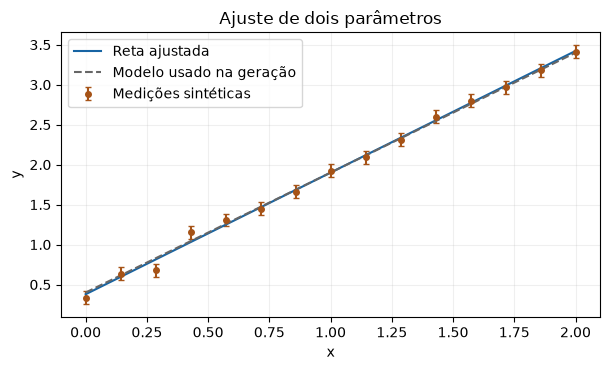

In [8]:
x_fino = np.linspace(x_dados.min(), x_dados.max(), 200)

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.errorbar(
    x_dados,
    y_dados,
    yerr=sigma,
    fmt="o",
    markersize=4,
    capsize=2,
    color="#a65317",
    label="Medições sintéticas",
)
ax.plot(
    x_fino, modelo_linear(x_fino, *parametros), color="#1764a3", label="Reta ajustada"
)
ax.plot(
    x_fino,
    modelo_linear(x_fino, a_verdadeiro, b_verdadeiro),
    "--",
    color="0.4",
    label="Modelo usado na geração",
)
ax.set(xlabel="x", ylabel="y", title="Ajuste de dois parâmetros")
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

### Exercício 2 · Ajuste com resposta conhecida

Ajuste uma reta aos pontos $(0,1)$, $(1,3)$, $(2,5)$ e $(3,7)$. Qual é a solução exata para os dois parâmetros? Confira o resíduo nos quatro pontos.


In [9]:
x_ex2 = np.array([0.0, 1.0, 2.0, 3.0])
y_ex2 = np.array([1.0, 3.0, 5.0, 7.0])


def reta_ex2(x, a, b):
    return a * x + b


parametros_ex2 = None  # Use curve_fit e separe os parâmetros da covariância.
print("Seus parâmetros:", parametros_ex2)

Seus parâmetros: None


<details>
<summary>Conferir uma solução do exercício 2</summary>

~~~python
import numpy as np
from scipy.optimize import curve_fit

def reta(x, a, b):
    return a * x + b

x = np.array([0.0, 1.0, 2.0, 3.0])
y = np.array([1.0, 3.0, 5.0, 7.0])
parametros, _ = curve_fit(reta, x, y, p0=(1.0, 0.0))
np.testing.assert_allclose(parametros, [2.0, 1.0], rtol=1e-10, atol=1e-10)
print("Parâmetros:", parametros)
print("Resíduos:", y - reta(x, *parametros))
~~~

A reta é $y=2x+1$. Aqui os dados não contêm ruído; o exercício verifica a implementação do ajuste.

</details>


## 3. Interpolação: passar pelos dados conhecidos

Agora o objetivo muda: construir uma função que passe pelos pontos fornecidos. Vamos amostrar $\sin(x)$ em cinco posições de $[0,\pi]$ e comparar uma interpolação linear com uma cúbica.

Conhecemos a função exata neste exemplo, o que permite observar o erro **entre** os pontos. Uma interpolação não é automaticamente adequada para remover ruído de medições.


In [10]:
x_nos = np.linspace(0.0, np.pi, 5)
y_nos = np.sin(x_nos)
x_consulta = np.linspace(0.0, np.pi, 201)

print("Nós:", np.round(x_nos, 3))
print("Valores:", np.round(y_nos, 3))

Nós: [0.    0.785 1.571 2.356 3.142]
Valores: [0.    0.707 1.    0.707 0.   ]


### Segmentos de reta com np.interp

**np.interp** é uma opção simples para interpolação linear unidimensional. Os nós devem estar em ordem crescente. Vamos consultar somente o intervalo coberto pelos dados.

Fora desse intervalo, o comportamento padrão é devolver o valor da extremidade correspondente. Isso não é extrapolação linear.


In [11]:
y_linear = np.interp(x_consulta, x_nos, y_nos)
np.testing.assert_allclose(np.interp(x_nos, x_nos, y_nos), y_nos, rtol=0.0, atol=1e-14)

print("Valor interpolado em pi/8:", np.interp(np.pi / 8, x_nos, y_nos))
print("Valor exato em pi/8:", np.sin(np.pi / 8))

Valor interpolado em pi/8: 0.35355339059327373
Valor exato em pi/8: 0.3826834323650898


### Polinômios cúbicos por partes com CubicSpline

Uma spline cúbica combina trechos cúbicos com continuidade de primeiras e segundas derivadas. Aqui escolhemos condições **naturais**: a segunda derivada é zero nas duas extremidades.

Essa condição combina com $\sin(x)$ nos extremos 0 e $\pi$, mas não serve automaticamente para qualquer aplicação. Desativamos extrapolação e continuamos dentro do intervalo.


In [12]:
spline = CubicSpline(x_nos, y_nos, bc_type="natural", extrapolate=False)
y_cubica = spline(x_consulta)

np.testing.assert_allclose(spline(x_nos), y_nos, rtol=0.0, atol=1e-14)
print("Erro máximo amostrado -- linear:", np.max(np.abs(y_linear - np.sin(x_consulta))))
print("Erro máximo amostrado -- cúbica:", np.max(np.abs(y_cubica - np.sin(x_consulta))))

Erro máximo amostrado -- linear: 0.07036523091870861
Erro máximo amostrado -- cúbica: 0.0010659753680805073


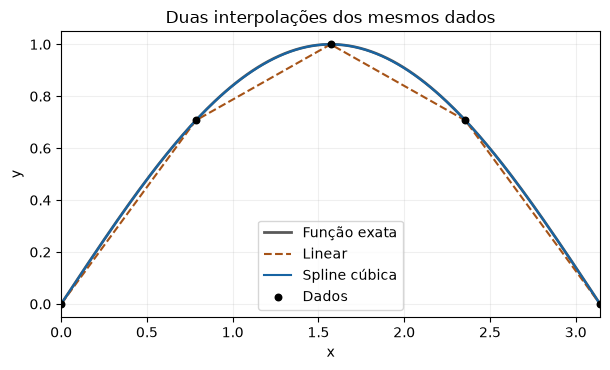

In [13]:
fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.plot(x_consulta, np.sin(x_consulta), color="0.35", linewidth=2, label="Função exata")
ax.plot(x_consulta, y_linear, "--", color="#a65317", label="Linear")
ax.plot(x_consulta, y_cubica, color="#1764a3", label="Spline cúbica")
ax.scatter(x_nos, y_nos, color="black", s=22, zorder=4, label="Dados")
ax.set(
    xlabel="x", ylabel="y", title="Duas interpolações dos mesmos dados", xlim=(0, np.pi)
)
ax.grid(alpha=0.2)
ax.legend()
fig.tight_layout()
plt.show()
plt.close(fig)

As duas interpolações reproduzem os valores nos nós, dentro do arredondamento numérico. Neste exemplo suave, a spline aproxima melhor entre os nós; isso não estabelece uma preferência universal. Splines cúbicas podem apresentar oscilações e ultrapassar a faixa dos dados.

O erro máximo acima foi medido numa grade finita. Ele não é uma prova do máximo sobre todo o intervalo.

### Exercício 3 · Interpolação linear à mão e no código

Para os dados $(0,0)$, $(1,2)$ e $(2,0)$, calcule os valores interpolados em $0{,}5$ e $1{,}5$. Antes de executar, desenhe mentalmente os dois segmentos.


In [14]:
x_ex3 = np.array([0.0, 1.0, 2.0])
y_ex3 = np.array([0.0, 2.0, 0.0])
consultas_ex3 = np.array([0.5, 1.5])

valores_ex3 = None  # Use np.interp.
print("Valores interpolados:", valores_ex3)

Valores interpolados: None


<details>
<summary>Conferir uma solução do exercício 3</summary>

~~~python
import numpy as np

x = np.array([0.0, 1.0, 2.0])
y = np.array([0.0, 2.0, 0.0])
consultas = np.array([0.5, 1.5])
valores = np.interp(consultas, x, y)
np.testing.assert_allclose(valores, [1.0, 1.0], rtol=0.0, atol=1e-14)
print(valores)
~~~

Cada consulta está no meio de um segmento cujos valores nas pontas são 0 e 2.

</details>


## 4. EDO: evolução de um estado

Considere o problema de valor inicial
\[
y'(t)=-2y(t),\qquad y(0)=1,\qquad 0\le t\le2.
\]
Sua solução exata é $y(t)=e^{-2t}$.

**solve_ivp** recebe a função que calcula a derivada, o intervalo e o estado inicial. Mesmo para uma única equação, o estado é representado por um vetor.


In [15]:
def derivada_estado(t, y):
    return -2.0 * y


tempos_saida = np.linspace(0.0, 2.0, 41)
solucao = solve_ivp(
    derivada_estado,
    t_span=(0.0, 2.0),
    y0=[1.0],
    method="RK45",
    t_eval=tempos_saida,
    rtol=1e-8,
    atol=1e-10,
)

print("Sucesso?", solucao.success)
print("Mensagem:", solucao.message)
print("Shape de y:", solucao.y.shape)
print("Avaliações da derivada:", solucao.nfev)
assert solucao.success

Sucesso? True
Mensagem: The solver successfully reached the end of the integration interval.
Shape de y: (1, 41)
Avaliações da derivada: 260


Cada linha de **solucao.y** corresponde a uma componente do estado; cada coluna corresponde a um tempo retornado. Portanto, **solucao.y[0]** contém nossa única variável nos 41 tempos solicitados.

As tolerâncias controlam estimativas de erro durante a integração. A comparação com a solução exata será feita separadamente.


Erro máximo nos tempos retornados: 7.358541553870168e-10


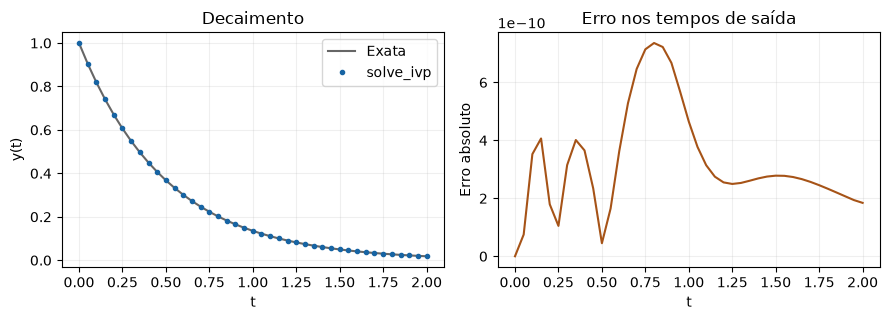

In [16]:
y_calculado = solucao.y[0]
y_exato = np.exp(-2.0 * solucao.t)
erro_amostrado = np.abs(y_calculado - y_exato)

print("Erro máximo nos tempos retornados:", erro_amostrado.max())
np.testing.assert_allclose(y_calculado, y_exato, rtol=1e-6, atol=1e-8)

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.3))
axes[0].plot(solucao.t, y_exato, color="0.4", label="Exata")
axes[0].plot(solucao.t, y_calculado, "o", ms=3, color="#1764a3", label="solve_ivp")
axes[0].set(xlabel="t", ylabel="y(t)", title="Decaimento")
axes[0].legend()
axes[1].plot(solucao.t, erro_amostrado, color="#a65317")
axes[1].set(xlabel="t", ylabel="Erro absoluto", title="Erro nos tempos de saída")
axes[1].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
for ax in axes:
    ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()
plt.close(fig)

### Tempos de saída não são os passos internos

**t_eval** escolhe onde queremos a resposta. O RK45 escolhe passos internos adaptativamente e avalia a solução nos tempos solicitados. Aumentar o número de tempos de saída não força passos internos menores.

Para observar os tempos dos passos aceitos, podemos resolver novamente sem t_eval. O vetor **t** dessa segunda execução inclui o instante inicial e as extremidades dos passos aceitos; não inclui tentativas rejeitadas.


In [17]:
solucao_passos = solve_ivp(
    derivada_estado,
    (0.0, 2.0),
    [1.0],
    method="RK45",
    rtol=1e-8,
    atol=1e-10,
)
assert solucao_passos.success

print("Tempos solicitados na primeira execução:", solucao.t.size)
print("Passos aceitos na segunda execução:", solucao_passos.t.size - 1)
print("Primeiros tempos aceitos:", np.round(solucao_passos.t[:6], 5))

Tempos solicitados na primeira execução: 41
Passos aceitos na segunda execução: 43
Primeiros tempos aceitos: [0.      0.00759 0.05459 0.10129 0.148   0.19472]


### Exercício 4 · Trocar a condição inicial

Resolva $y'=-2y$ com $y(0)=3$ em $[0,1]$. Compare a resposta em $t=1$ com $3e^{-2}$.

Mantenha a equação e altere apenas o estado inicial e o intervalo.


In [18]:
def derivada_ex4(t, y):
    return -2.0 * y


solucao_ex4 = None  # Use solve_ivp com y0=[3.0] e t_eval=[1.0].
if solucao_ex4 is None:
    print("Preencha solucao_ex4 para comparar y(1).")
else:
    print("Sucesso?", solucao_ex4.success)
    print("y(1):", solucao_ex4.y[0, -1])
    print("Valor exato:", 3.0 * np.exp(-2.0))

Preencha solucao_ex4 para comparar y(1).


<details>
<summary>Conferir uma solução do exercício 4</summary>

~~~python
import numpy as np
from scipy.integrate import solve_ivp

def derivada(t, y):
    return -2.0 * y

solucao = solve_ivp(
    derivada, (0.0, 1.0), [3.0], t_eval=[1.0],
    rtol=1e-8, atol=1e-10,
)
assert solucao.success
valor_exato = 3.0 * np.exp(-2.0)
np.testing.assert_allclose(solucao.y[0, -1], valor_exato, rtol=1e-6, atol=1e-8)
print(solucao.y[0, -1], valor_exato)
~~~

A condição inicial multiplica a solução por 3 porque esta EDO é linear e homogênea.

</details>


## O que cada verificação mostrou?

| Problema | O que verificamos | O que não se conclui só com isso |
|---|---|---|
| Raiz | Convergência, resíduo e resposta conhecida | Superioridade geral de um método |
| Ajuste | Parâmetros, resíduos e gráfico | Validade física do modelo para novos dados |
| Interpolação | Reprodução nos nós e erro amostrado | Ausência de oscilações em qualquer aplicação |
| EDO | Sucesso e comparação nos tempos retornados | Um limite rigoroso do erro em todo o intervalo |

**np.testing.assert_allclose** é uma verificação automática: fica silenciosa quando os valores estão dentro das tolerâncias e gera um erro quando não estão. Tolerância absoluta e relativa devem ser escolhidas conforme a escala do problema.


## Referências e autoria

Estes tópicos retomam ideias do [curso NumPy/SciPy de Diego Volpatto](https://github.com/volpatto/numpy_scipy_course), com redação, exemplos e verificações novos para este módulo.

Fontes oficiais: [root_scalar](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.root_scalar.html), [newton](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.newton.html), [curve_fit](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.curve_fit.html), [np.interp](https://numpy.org/doc/stable/reference/generated/numpy.interp.html), [CubicSpline](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.CubicSpline.html) e [solve_ivp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.solve_ivp.html).

**Autor:** Diego Tavares Volpatto. **Licença:** [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/).


[← Caderno anterior](07-organizacao-e-dataclasses.ipynb) · [Índice do curso](../README.md)

Autor: Diego Tavares Volpatto · [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/deed.pt-br)